In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Shiller data : http://www.econ.yale.edu/~shiller/data.htm
df = pd.read_excel(r"C:\Users\bbrown\Downloads\ie_data (3).xls", sheet_name='Data', header=7)

In [3]:
df.head(2)

,Date,P,D,E,CPI,Fraction,Rate GS10,Price,Dividend,Price.1,...,CAPE,Unnamed: 13,TR CAPE,Unnamed: 15,Yield,Returns,Returns.1,Real Return,Real Return.1,Returns.2
0,1871.01,4.44,0.26,0.4,12.464061,1871.041667,5.32,118.545708,6.941866,118.545708,...,NaN,NaN,NaN,NaN,NaN,1.004177,1.000000,0.130609,0.092504,0.038106
1,1871.02,4.5,0.26,0.4,12.844641,1871.125000,5.323333,116.587763,6.736182,117.149112,...,NaN,NaN,NaN,NaN,NaN,1.004180,0.974424,0.130858,0.094635,0.036224


In [4]:
df= df[~df['Date'].isna()]

In [5]:
df[df['Date'] == 1871]

,Date,P,D,E,CPI,Fraction,Rate GS10,Price,Dividend,Price.1,...,CAPE,Unnamed: 13,TR CAPE,Unnamed: 15,Yield,Returns,Returns.1,Real Return,Real Return.1,Returns.2


In [6]:
df['year'] = df['Date'].astype(int)
# 2. Extract the Month 
# We multiply by 100 and use round to handle floating point precision 
# (e.g., 1871.1 becomes 187110, then we take the remainder)
df['month'] = (df['Date'] * 100 % 100).round().astype(int)

# 3. Convert to Datetime
df['datetime'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['month'].astype(str) + '-01'
)



df = df.sort_values(by='datetime', ascending=True)
df.reset_index(drop=True, inplace=True)

In [7]:
df = df[df['datetime'] > "1950"]

In [8]:
df['Value'] = pd.to_numeric(df['TR CAPE'], errors='coerce')

In [9]:
df

,Date,P,D,E,CPI,Fraction,Rate GS10,Price,Dividend,Price.1,...,Yield,Returns,Returns.1,Real Return,Real Return.1,Returns.2,year,month,datetime,Value
949,1950.02,17.21,1.16,2.353330,23.5,1950.125000,2.340833,243.711176,16.426785,1.620798e+04,...,0.121397,1.000110,11.572921,0.154187,-0.010084,0.164271,1950,2,1950-02-01,14.060925
950,1950.03,17.35,1.17,2.370000,23.6,1950.208333,2.361667,244.652644,16.498190,1.636203e+04,...,0.121641,1.000130,11.525155,0.151853,-0.007407,0.159260,1950,3,1950-03-01,14.056777
951,1950.04,17.84,1.18,2.426670,23.6,1950.291667,2.3825,251.562142,16.639200,1.691686e+04,...,0.119243,1.000149,11.526649,0.149434,-0.007646,0.157080,1950,4,1950-04-01,14.394941
952,1950.05,18.44,1.19,2.483330,23.7,1950.375000,2.403333,258.925610,16.709408,1.750567e+04,...,0.117267,1.000168,11.479722,0.144791,-0.007446,0.152237,1950,5,1950-05-01,14.750478
953,1950.06,18.74,1.20,2.540000,23.8,1950.458333,2.424167,262.032444,16.779025,1.781026e+04,...,0.116053,1.000187,11.433408,0.146908,-0.005426,0.152335,1950,6,1950-06-01,14.858174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860,2026.01,6929.122,79.67,261.106667,325.252,2026.041667,4.21,7089.582649,81.514952,4.813124e+06,...,0.015354,1.010009,40.585060,NaN,NaN,NaN,2026,1,2026-01-01,42.344476
1861,2026.02,6893.806316,79.82,269.103333,326.785,2026.125000,4.13,7020.360301,81.285306,4.770727e+06,...,0.016976,0.993745,40.798973,NaN,NaN,NaN,2026,2,2026-02-01,41.630793
1862,2026.03,6654.419091,79.97,277.100000,330.213,2026.208333,4.25,6706.229624,80.592637,4.561822e+06,...,0.017803,0.997904,40.122885,NaN,NaN,NaN,2026,3,2026-03-01,39.473612
1863,2026.04,6957.007619,NaN,NaN,331.927,2026.291667,4.32,6974.969868,NaN,4.744629e+06,...,0.016295,0.993192,39.832021,NaN,NaN,NaN,2026,4,2026-04-01,40.702190


<Axes: >

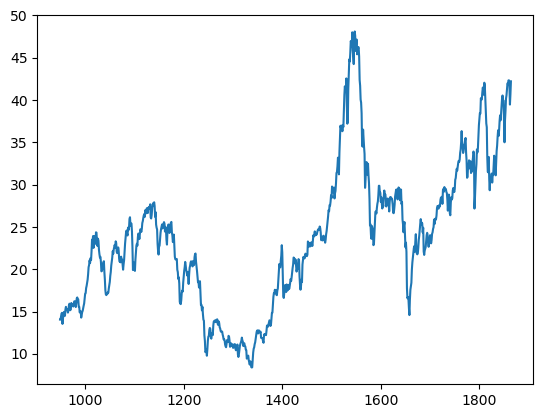

In [10]:
df['Value'].plot()

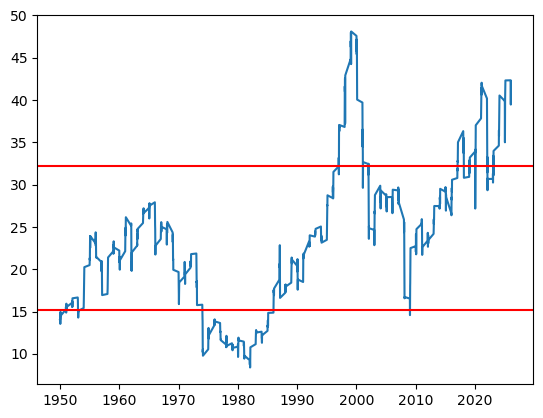

In [11]:
stand_dev_1 = df['Value'].mean() + df['Value'].std()
stand_dev_2 = df['Value'].mean() - df['Value'].std()

fig, ax = plt.subplots()
ax.plot(df['Date'], df['Value'])
ax.axhline(y=stand_dev_1, color='red')
ax.axhline(y=stand_dev_2, color='red')

<Axes: >

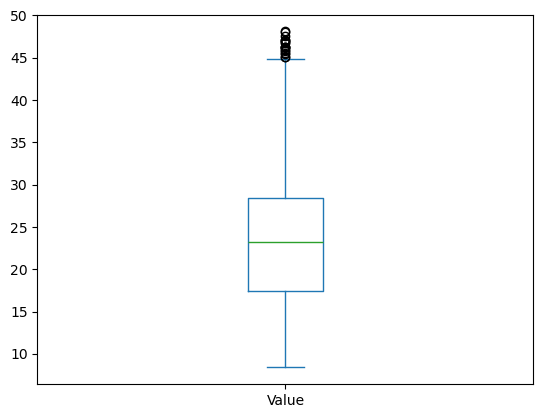

In [12]:
df['Value'].plot(kind='box')

In [13]:
# Calculate Velocity
df['roc_12m'] = df['Value'].pct_change(periods=12)
# Normalize
df['roc_zscore'] = (df['roc_12m'] - df['roc_12m'].mean()) / df['roc_12m'].std()
df

,Date,P,D,E,CPI,Fraction,Rate GS10,Price,Dividend,Price.1,...,Returns.1,Real Return,Real Return.1,Returns.2,year,month,datetime,Value,roc_12m,roc_zscore
949,1950.02,17.21,1.16,2.353330,23.5,1950.125000,2.340833,243.711176,16.426785,1.620798e+04,...,11.572921,0.154187,-0.010084,0.164271,1950,2,1950-02-01,14.060925,NaN,NaN
950,1950.03,17.35,1.17,2.370000,23.6,1950.208333,2.361667,244.652644,16.498190,1.636203e+04,...,11.525155,0.151853,-0.007407,0.159260,1950,3,1950-03-01,14.056777,NaN,NaN
951,1950.04,17.84,1.18,2.426670,23.6,1950.291667,2.3825,251.562142,16.639200,1.691686e+04,...,11.526649,0.149434,-0.007646,0.157080,1950,4,1950-04-01,14.394941,NaN,NaN
952,1950.05,18.44,1.19,2.483330,23.7,1950.375000,2.403333,258.925610,16.709408,1.750567e+04,...,11.479722,0.144791,-0.007446,0.152237,1950,5,1950-05-01,14.750478,NaN,NaN
953,1950.06,18.74,1.20,2.540000,23.8,1950.458333,2.424167,262.032444,16.779025,1.781026e+04,...,11.433408,0.146908,-0.005426,0.152335,1950,6,1950-06-01,14.858174,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1860,2026.01,6929.122,79.67,261.106667,325.252,2026.041667,4.21,7089.582649,81.514952,4.813124e+06,...,40.585060,NaN,NaN,NaN,2026,1,2026-01-01,42.344476,0.061266,0.229124
1861,2026.02,6893.806316,79.82,269.103333,326.785,2026.125000,4.13,7020.360301,81.285306,4.770727e+06,...,40.798973,NaN,NaN,NaN,2026,2,2026-02-01,41.630793,0.042245,0.105584
1862,2026.03,6654.419091,79.97,277.100000,330.213,2026.208333,4.25,6706.229624,80.592637,4.561822e+06,...,40.122885,NaN,NaN,NaN,2026,3,2026-03-01,39.473612,0.056896,0.200744
1863,2026.04,6957.007619,NaN,NaN,331.927,2026.291667,4.32,6974.969868,NaN,4.744629e+06,...,39.832021,NaN,NaN,NaN,2026,4,2026-04-01,40.702190,0.162410,0.886040


<Axes: >

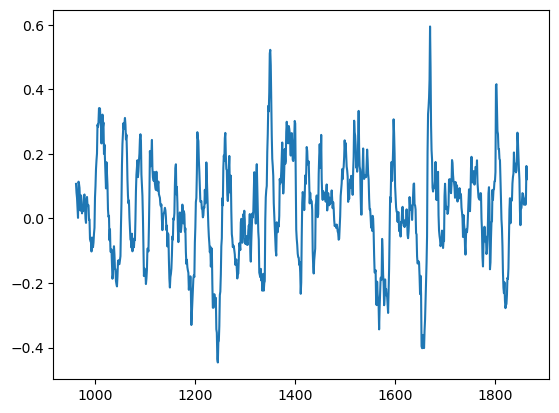

In [14]:
df['roc_12m'].plot()

<Axes: >

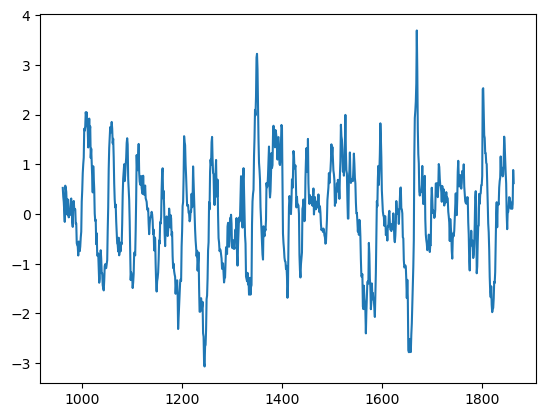

In [15]:
df['roc_zscore'].plot()

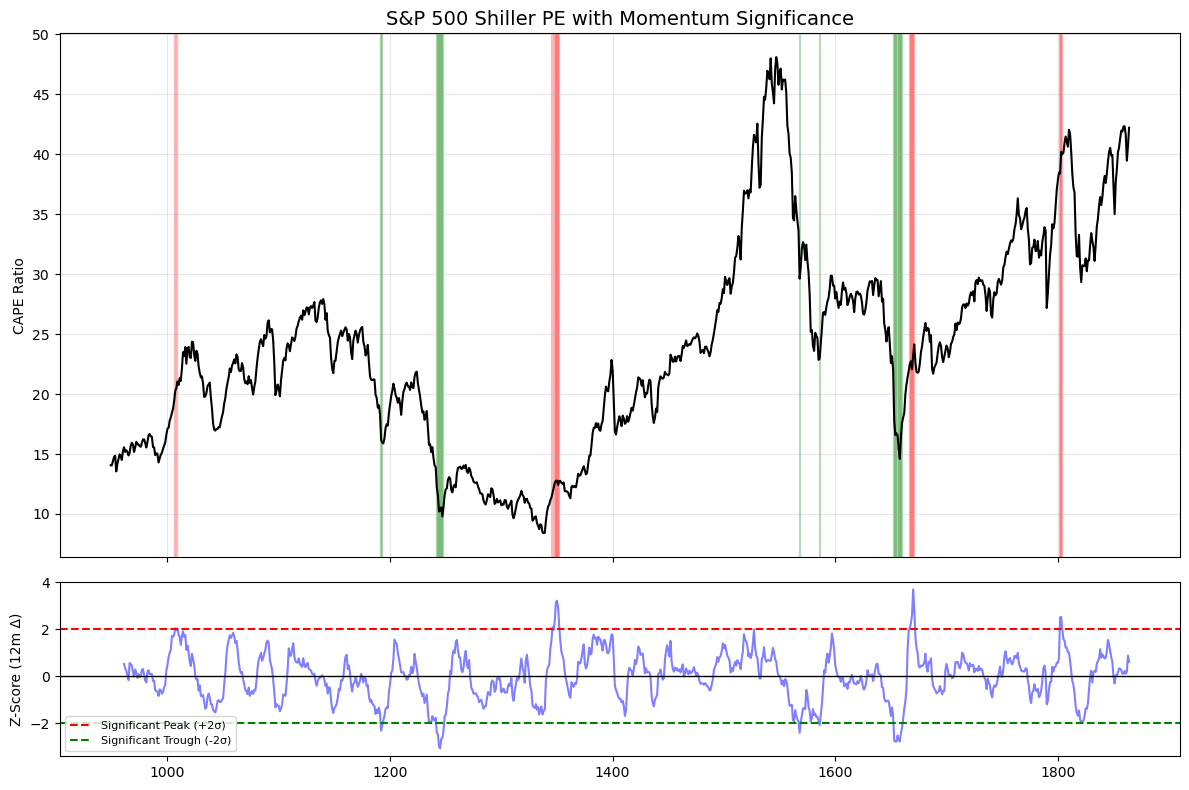

In [16]:
# 4. VISUALIZE: Create the Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# Top Plot: Shiller PE Ratio
ax1.plot(df.index, df['Value'], color='black', lw=1.5, label='Shiller PE')
ax1.set_title('S&P 500 Shiller PE with Momentum Significance', fontsize=14)
ax1.set_ylabel('CAPE Ratio')
ax1.grid(alpha=0.3)

# Bottom Plot: The Z-Score (The Signal)
ax2.plot(df.index, df['roc_zscore'], color='blue', alpha=0.5)
ax2.axhline(0, color='black', lw=1)
ax2.axhline(2, color='red', linestyle='--', label='Significant Peak (+2σ)')
ax2.axhline(-2, color='green', linestyle='--', label='Significant Trough (-2σ)')
ax2.set_ylabel('Z-Score (12m Δ)')
ax2.legend(loc='lower left', fontsize=8)

# 5. HIGHLIGHT SIGNIFICANCE: Shade the background where Z > 2 or Z < -2
# This identifies the "peaks and troughs" you were looking for.
for i in range(1, len(df)):
    z = df['roc_zscore'].iloc[i]
    if z > 2:
        ax1.axvspan(df.index[i-1], df.index[i], color='red', alpha=0.2)
    elif z < -2:
        ax1.axvspan(df.index[i-1], df.index[i], color='green', alpha=0.2)

plt.tight_layout()
plt.show()

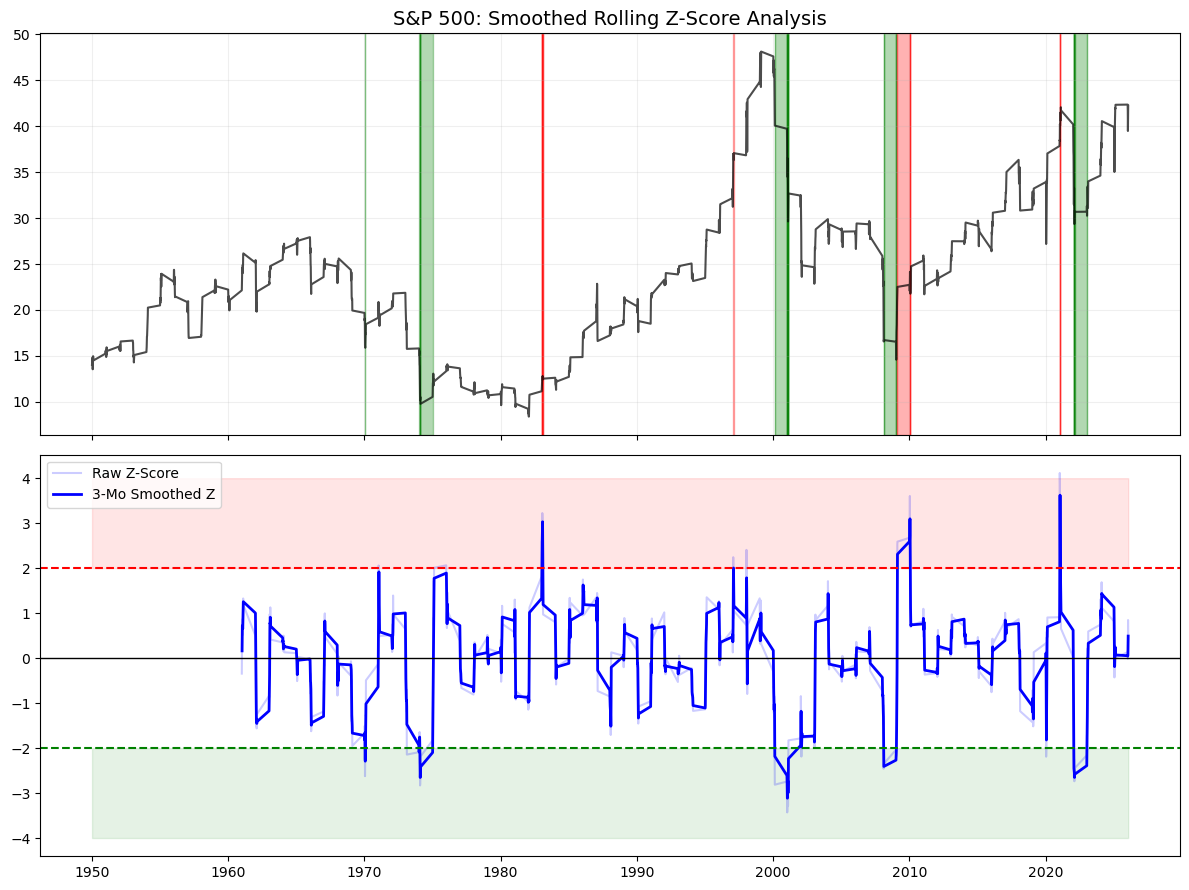

In [17]:
# 2. PARAMETERS
WINDOW_SIZE = 120  # 10-year rolling window (120 months)
SMOOTHING_PERIOD = 3 # 3-month window to smooth the Z-score signal
df = df.set_index('Date')

# Calculate rolling mean and std of the RoC
df['rolling_mu'] = df['roc_12m'].rolling(window=WINDOW_SIZE).mean()
df['rolling_sigma'] = df['roc_12m'].rolling(window=WINDOW_SIZE).std()

# Calculate the Rolling Z-Score
df['rolling_zscore'] = (df['roc_12m'] - df['rolling_mu']) / df['rolling_sigma']

# 4. SMOOTH THE SIGNAL
# This reduces "false positive" spikes
df['smoothed_z'] = df['rolling_zscore'].rolling(window=SMOOTHING_PERIOD).mean()

# 5. VISUALIZE
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Top Plot: CAPE Ratio
ax1.plot(df.index, df['Value'], color='black', label='Shiller PE', alpha=0.7)
ax1.set_title('S&P 500: Smoothed Rolling Z-Score Analysis', fontsize=14)
ax1.grid(alpha=0.2)

# Bottom Plot: Smoothed Z-Score
ax2.plot(df.index, df['rolling_zscore'], color='blue', alpha=0.2, label='Raw Z-Score')
ax2.plot(df.index, df['smoothed_z'], color='blue', lw=2, label=f'{SMOOTHING_PERIOD}-Mo Smoothed Z')
ax2.axhline(0, color='black', lw=1)
ax2.axhline(2, color='red', linestyle='--')
ax2.axhline(-2, color='green', linestyle='--')
ax2.fill_between(df.index, 2, 4, color='red', alpha=0.1) # Overheated Zone
ax2.fill_between(df.index, -2, -4, color='green', alpha=0.1) # Value Zone
ax2.legend(loc='upper left')

# Highlight sustained significant periods
# We use the 'smoothed_z' to decide when to shade the background
for i in range(1, len(df)):
    z = df['smoothed_z'].iloc[i]
    if z > 2:
        ax1.axvspan(df.index[i-1], df.index[i], color='red', alpha=0.3)
    elif z < -2:
        ax1.axvspan(df.index[i-1], df.index[i], color='green', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
df.columns

Index(['P', 'D', 'E', 'CPI', 'Fraction', 'Rate GS10', 'Price', 'Dividend',
       'Price.1', 'Earnings', 'Earnings.1', 'CAPE', 'Unnamed: 13', 'TR CAPE',
       'Unnamed: 15', 'Yield', 'Returns', 'Returns.1', 'Real Return',
       'Real Return.1', 'Returns.2', 'year', 'month', 'datetime', 'Value',
       'roc_12m', 'roc_zscore', 'rolling_mu', 'rolling_sigma',
       'rolling_zscore', 'smoothed_z'],
      dtype='str')

In [19]:
df['Yield_y'] = df['Rate GS10']

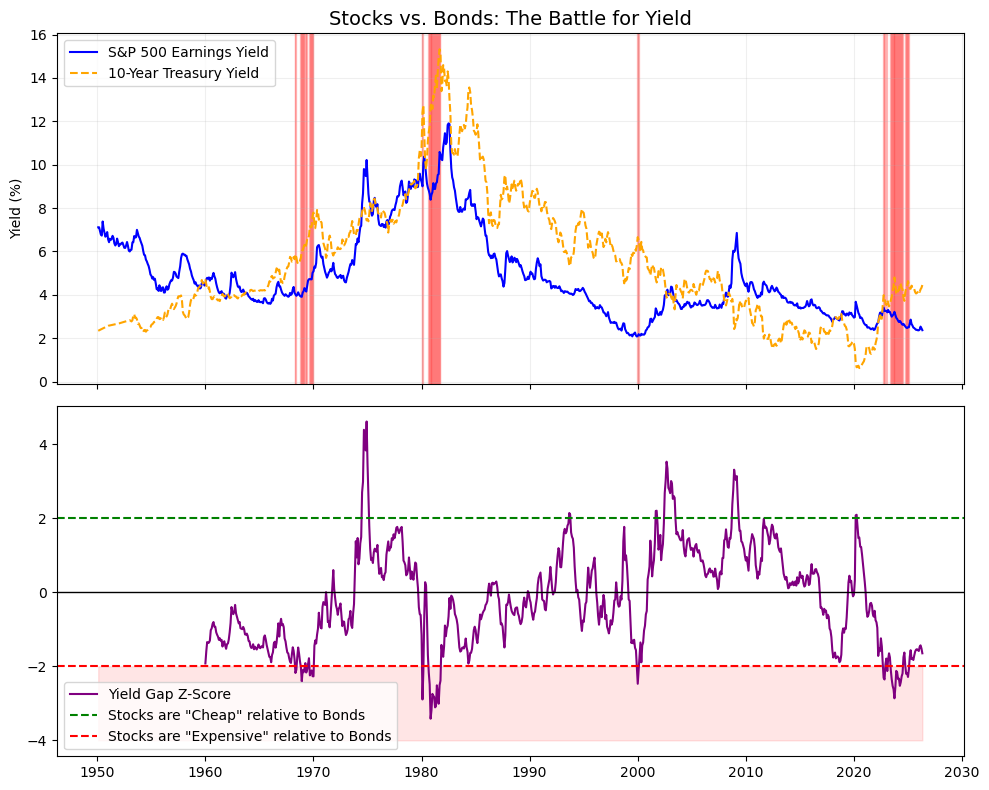

In [20]:
df.set_index('datetime', inplace=True)
# 2. CALCULATE YIELDS
# Convert PE to a percentage yield (e.g., 20 PE -> 5.0%)
df['earnings_yield'] = (1 / df['Value']) * 100

# Calculate the Yield Gap (Stocks minus Bonds)
# A positive gap means stocks pay more than bonds; negative means bonds pay more.
df['yield_gap'] = df['earnings_yield'] - df['Yield_y']

# 3. CALCULATE THE ROLLING Z-SCORE OF THE GAP
WINDOW = 120 # 10-year rolling window
df['gap_mu'] = df['yield_gap'].rolling(window=WINDOW).mean()
df['gap_sigma'] = df['yield_gap'].rolling(window=WINDOW).std()
df['gap_zscore'] = (df['yield_gap'] - df['gap_mu']) / df['gap_sigma']

# 4. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: The Two Yields
ax1.plot(df.index, df['earnings_yield'], label='S&P 500 Earnings Yield', color='blue', lw=1.5)
ax1.plot(df.index, df['Yield_y'], label='10-Year Treasury Yield', color='orange', lw=1.5, linestyle='--')
ax1.set_title('Stocks vs. Bonds: The Battle for Yield', fontsize=14)
ax1.set_ylabel('Yield (%)')
ax1.legend()
ax1.grid(alpha=0.2)

# Bottom Plot: The Yield Gap Z-Score
ax2.plot(df.index, df['gap_zscore'], color='purple', label='Yield Gap Z-Score')
ax2.axhline(0, color='black', lw=1)
ax2.axhline(2, color='green', linestyle='--', label='Stocks are "Cheap" relative to Bonds')
ax2.axhline(-2, color='red', linestyle='--', label='Stocks are "Expensive" relative to Bonds')
ax2.fill_between(df.index, -2, -4, color='red', alpha=0.1) # Danger Zone
ax2.legend(loc='lower left')

# Highlight Regimes
for i in range(1, len(df)):
    if df['gap_zscore'].iloc[i] < -2:
        ax1.axvspan(df.index[i-1], df.index[i], color='red', alpha=0.2)

plt.tight_layout()
plt.show()

In [23]:
df.tail()

,P,D,E,CPI,Fraction,Rate GS10,Price,Dividend,Price.1,Earnings,...,rolling_mu,rolling_sigma,rolling_zscore,smoothed_z,Yield_y,earnings_yield,yield_gap,gap_mu,gap_sigma,gap_zscore
datetime,,,,,,,,,,,,,,,,,,,,,
2026-01-01,6929.122,79.67,261.106667,325.252,2026.041667,4.21,7089.582649,81.514952,4.813124e+06,267.153226,...,0.043123,0.137331,0.132109,0.052738,4.21,2.361583,-1.848417,0.227629,1.308950,-1.586038
2026-02-01,6893.806316,79.82,269.103333,326.785,2026.125000,4.13,7020.360301,81.285306,4.770727e+06,274.043434,...,0.044409,0.136586,-0.015847,0.043630,4.13,2.402068,-1.727932,0.196484,1.310661,-1.468279
2026-03-01,6654.419091,79.97,277.100000,330.213,2026.208333,4.25,6706.229624,80.592637,4.561822e+06,279.257468,...,0.045315,0.136302,0.084967,0.067076,4.25,2.533338,-1.716662,0.168054,1.314878,-1.433377
2026-04-01,6957.007619,NaN,NaN,331.927,2026.291667,4.32,6974.969868,NaN,4.744629e+06,NaN,...,0.046947,0.136524,0.845737,0.304952,4.32,2.456870,-1.86313,0.138367,1.320220,-1.516032
2026-05-01,7259.22,NaN,NaN,332.784,2026.375000,4.45,7259.220000,NaN,4.937986e+06,NaN,...,0.048313,0.136444,0.537841,0.489515,4.45,2.368673,-2.081327,0.106600,1.327427,-1.648247
